In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files

uploaded = files.upload()

Saving creditcard.csv to creditcard.csv


In [3]:
df = pd.read_csv("creditcard.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
missing_values = df.isnull().sum()

print(missing_values)
print("\nTotal missing values:", df.isnull().sum().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Total missing values: 0


### Missing Value Analysis

The dataset was checked for missing values using `isnull().sum()`.

No missing values were found in the dataset. Therefore, no missing-value imputation was required.

In [5]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 1081


In [6]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (283726, 31)


In [7]:
print("Duplicate rows after cleaning:", df.duplicated().sum())

Duplicate rows after cleaning: 0


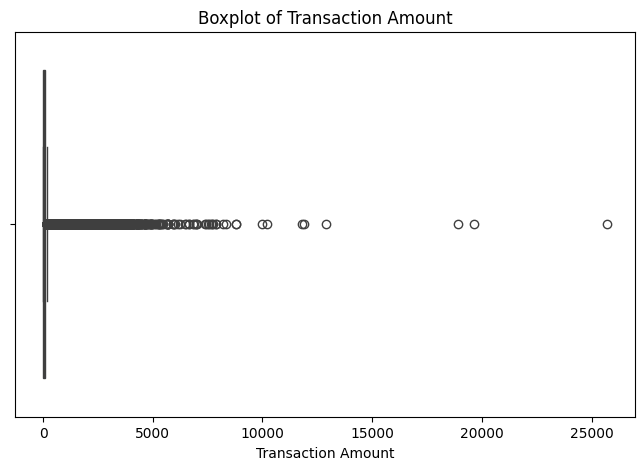

In [8]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["Amount"])

plt.title("Boxplot of Transaction Amount")
plt.xlabel("Transaction Amount")

plt.show()

In [9]:
Q1 = df["Amount"].quantile(0.25)
Q3 = df["Amount"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 5.6
Q3: 77.51
IQR: 71.91000000000001
Lower Bound: -102.26500000000001
Upper Bound: 185.375


In [10]:
outliers = df[
    (df["Amount"] < lower_bound) |
    (df["Amount"] > upper_bound)
]

print("Number of Amount outliers:", len(outliers))

Number of Amount outliers: 31685


### Outlier Analysis

The IQR method was used to identify potential outliers in the `Amount` feature.

The detected values were treated as potential outliers rather than automatically removed because unusual transaction amounts may contain useful information for fraud analysis.

In [11]:
print("Final dataset shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Final dataset shape: (283726, 31)
Missing values: 0
Duplicate rows: 0


## Week 3 — Conclusion

The Credit Card Fraud Detection dataset was cleaned and prepared for further analysis.

The dataset originally contained 284,807 records and 31 columns. No missing values were found.

A total of 1,081 duplicate records were identified and removed, resulting in 283,726 records.

Potential outliers in the `Amount` feature were identified using the IQR method and visualized using a boxplot. These outliers were retained because unusual transaction amounts may provide useful information for fraud analysis.

The cleaned dataset is now ready for exploratory data analysis in Week 4.